# Data Analysis

Log

- 19/01/2025: Init

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data

In [2]:
fpath_records = './data/records.json'
def get_df() -> pd.DataFrame:
    return pd.read_json(fpath_records)

In [3]:
df = get_df()
print('df.shape: ', df.shape)
print('df ∑nRecords: ', df.nRecords.sum())
print('df head')
display(df.head(3))
print('df tail')
display(df.tail(3))

# df.records: each value in this column is a list of records
# a: dataframe with exploded df.records, i.e., each row corresponds to a single record object
a = df.explode('records',)
print('a.shape: ', a.shape)
display(a.head(3))

# b: dataframe created from the records objects
b = a.records.apply(pd.Series)
print('b.shape: ', b.shape)
display(b.head(3))

df.shape:  (600, 6)
df ∑nRecords:  112782
df head


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
0,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01,0
1,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",11,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,vc01,0
2,[{'name': 'https://www.w3.org/2018/credentials...,7,ed25519-signature-2020,Implementation_Ed25519Signature2020,vc01,0


df tail


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
597,[{'name': 'https://www.w3.org/2018/credentials...,258,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,vc01,149
598,[{'name': 'https://www.w3.org/2018/credentials...,254,ed25519-signature-2020,Implementation_Ed25519Signature2020,vc01,149
599,[{'name': 'https://www.w3.org/2018/credentials...,258,ecdsa-sd-2023-cryptosuite,Implementation_EcdsaSd2023Cryptosuite,vc01,149


a.shape:  (112782, 6)


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
0,"{'name': 'START_SIGN_VC', 'entryType': 'mark',...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01,0
0,"{'name': 'END_SIGN_VC', 'entryType': 'mark', '...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01,0
0,"{'name': 'START_VERIFY_VC', 'entryType': 'mark...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01,0


b.shape:  (112782, 16)


,name,entryType,startTime,duration,detail,initiatorType,workerStart,redirectStart,redirectEnd,fetchStart,requestStart,responseStart,responseEnd,transferSize,encodedBodySize,decodedBodySize
0,START_SIGN_VC,mark,464.831375,0.0,{'implementation': 'bbs-bls-signature-2020'},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,END_SIGN_VC,mark,594.743417,0.0,{'implementation': 'bbs-bls-signature-2020'},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,START_VERIFY_VC,mark,595.030667,0.0,{'implementation': 'bbs-bls-signature-2020'},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`c = merge(a,b)`

In [4]:
c = a[['iteration','implementationClass', 'credentialSetupKey']]\
    .drop_duplicates()\
    .merge(b[['name', 'entryType', 'startTime']], left_index=True, right_index=True)
print('c.shape: ', c.shape)
display(c.head(3))

c.shape:  (112782, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc01,START_SIGN_VC,mark,464.831375
0,0,Implementation_BbsBlsSignature2020,vc01,END_SIGN_VC,mark,594.743417
0,0,Implementation_BbsBlsSignature2020,vc01,START_VERIFY_VC,mark,595.030667


Filter: only keep `mark` entries.

In [5]:
d = c[c.entryType == 'mark']
print('d.shape: ', d.shape)
d.head(3)

d.shape:  (4200, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc01,START_SIGN_VC,mark,464.831375
0,0,Implementation_BbsBlsSignature2020,vc01,END_SIGN_VC,mark,594.743417
0,0,Implementation_BbsBlsSignature2020,vc01,START_VERIFY_VC,mark,595.030667


Some final preprocessing.

In [6]:
e = d.drop('entryType', axis = 1) # We can drop the entryType as we already know all values are 'mark'.
# Extract implementation column.
e['implementation'] = e.implementationClass.str.split('_').apply(lambda x: x[-1])
e.drop('implementationClass', axis=1, inplace=True) # We no longer need this column.
# Extract step and step type from name as columns.
e['step'] = e['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
e['stepType'] = e['name'].apply(lambda x: x.split('_')[0])
e.drop('name', axis=1, inplace=True) # We no longer need this column.
print('e.shape: ', e.shape)
display(e.head(3))

e.shape:  (4200, 6)


,iteration,credentialSetupKey,startTime,implementation,step,stepType
0,0,vc01,464.831375,BbsBlsSignature2020,SIGN_VC,START
0,0,vc01,594.743417,BbsBlsSignature2020,SIGN_VC,END
0,0,vc01,595.030667,BbsBlsSignature2020,VERIFY_VC,START


## Analysis

In [7]:
def get_dfa() -> pd.DataFrame:
    """ Get the analysis dataframe """
    # Return a copy of the last dataframe result from the previous section
    return e.copy()

**Background** 

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [8]:
dfa = get_dfa()
dfa.set_index(['implementation', 'credentialSetupKey', 'iteration','step','stepType'], inplace=True)
print('dfa.shape: ', dfa.shape)
display(dfa.head(3))

dfa.shape:  (4200, 1)


startTime
implementation      credentialSetupKey iteration step      stepType            
BbsBlsSignature2020 vc01               0         SIGN_VC   START     464.831375
                                                           END       594.743417
                                                 VERIFY_VC START     595.030667

In [9]:
# Compute the duration delta between each step's start and end time
df_delta = dfa.startTime\
    .unstack('stepType')\
    .apply(lambda r: r.END - r.START, axis=1)\
    .to_frame('delta')
print('df_delta.shape: ', df_delta.shape)
display(df_delta.head(3))

df_delta.shape:  (2100, 1)


delta
implementation      credentialSetupKey iteration step                      
BbsBlsSignature2020 vc01               0         DERIVE          176.389958
                                                 SIGN_VC         129.912042
                                                 VERIFY_DERIVED   44.007625

`df_stat`: the DataFrame containing descriptive statistics from `df_delta`.

In [10]:
df_stat = df_delta.copy()
df_stat.reset_index(inplace=True)
agg_funcs = ['mean','std', 'var','min','max','count']
df_stat = df_stat.groupby(['implementation', 'credentialSetupKey', 'step'])['delta'].agg(agg_funcs)
df_stat

mean  \
implementation           credentialSetupKey step                         
BbsBlsSignature2020      vc01               DERIVE          172.180203   
                                            SIGN_VC          72.597639   
                                            VERIFY_DERIVED   42.813602   
                                            VERIFY_VC        42.876041   
BbsTermwiseSignature2023 vc01               DERIVE          163.820333   
                                            SIGN_VC          54.722767   
                                            VERIFY_DERIVED   75.492197   
                                            VERIFY_VC        64.771569   
EcdsaSd2023Cryptosuite   vc01               DERIVE           51.976882   
                                            SIGN_VC          49.822199   
                                            VERIFY_DERIVED   16.419530   
                                            VERIFY_VC        17.375694   
Ed25519Signature2020     vc01               SIGN_VC          16.877371   
                                            VERIFY_VC        17.834239   

                                                                  std  \
implementation           credentialSetupKey step                        
BbsBlsSignature2020      vc01               DERIVE          26.447738   
                                            SIGN_VC         14.016870   
                                            VERIFY_DERIVED   5.375255   
                                            VERIFY_VC        8.701952   
BbsTermwiseSignature2023 vc01               DERIVE          17.880206   
                                            SIGN_VC         10.377723   
                                            VERIFY_DERIVED   6.499347   
                                            VERIFY_VC        2.766218   
EcdsaSd2023Cryptosuite   vc01               DERIVE          16.647853   
                                            SIGN_VC         21.088334   
                                            VERIFY_DERIVED   2.587968   
                                            VERIFY_VC        7.555180   
Ed25519Signature2020     vc01               SIGN_VC          5.898367   
                                            VERIFY_VC        6.923245   

                                                                   var  \
implementation           credentialSetupKey step                         
BbsBlsSignature2020      vc01               DERIVE          699.482836   
                                            SIGN_VC         196.472634   
                                            VERIFY_DERIVED   28.893363   
                                            VERIFY_VC        75.723968   
BbsTermwiseSignature2023 vc01               DERIVE          319.701757   
                                            SIGN_VC         107.697132   
                                            VERIFY_DERIVED   42.241514   
                                            VERIFY_VC         7.651963   
EcdsaSd2023Cryptosuite   vc01               DERIVE          277.151014   
                                            SIGN_VC         444.717820   
                                            VERIFY_DERIVED    6.697576   
                                            VERIFY_VC        57.080739   
Ed25519Signature2020     vc01               SIGN_VC          34.790738   
                                            VERIFY_VC        47.931326   

                                                                   min  \
implementation           credentialSetupKey step                         
BbsBlsSignature2020      vc01               DERIVE          137.108792   
                                            SIGN_VC          63.457167   
                                            VERIFY_DERIVED   38.828625   
                                            VERIFY_VC        39.959250   
BbsTermwiseSignature2023 vc01               DERIVE          152.558875   
         

`df_mean`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [11]:
step_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
df_mean = df_stat['mean']\
    .unstack(['implementation','credentialSetupKey'])\
    .reorder_levels(['credentialSetupKey','implementation'],axis=1)\
    .loc[step_order]\
    .round(2)
df_mean

credentialSetupKey                vc01                           \
implementation     BbsBlsSignature2020 BbsTermwiseSignature2023   
step                                                              
SIGN_VC                          72.60                    54.72   
VERIFY_VC                        42.88                    64.77   
DERIVE                          172.18                   163.82   
VERIFY_DERIVED                   42.81                    75.49   

credentialSetupKey                                              
implementation     EcdsaSd2023Cryptosuite Ed25519Signature2020  
step                                                            
SIGN_VC                             49.82                16.88  
VERIFY_VC                           17.38                17.83  
DERIVE                              51.98                  NaN  
VERIFY_DERIVED                      16.42                  NaN

Plotting (Seaborn)

In [12]:
dfsb = df_delta.reset_index()
print('dfsb.shape: ', dfsb.shape)
dfsb.head(3)

dfsb.shape:  (2100, 5)


,implementation,credentialSetupKey,iteration,step,delta
0,BbsBlsSignature2020,vc01,0,DERIVE,176.389958
1,BbsBlsSignature2020,vc01,0,SIGN_VC,129.912042
2,BbsBlsSignature2020,vc01,0,VERIFY_DERIVED,44.007625


In [13]:
implementation_order = sorted(dfsb.implementation.unique())
print(implementation_order)

['BbsBlsSignature2020', 'BbsTermwiseSignature2023', 'EcdsaSd2023Cryptosuite', 'Ed25519Signature2020']


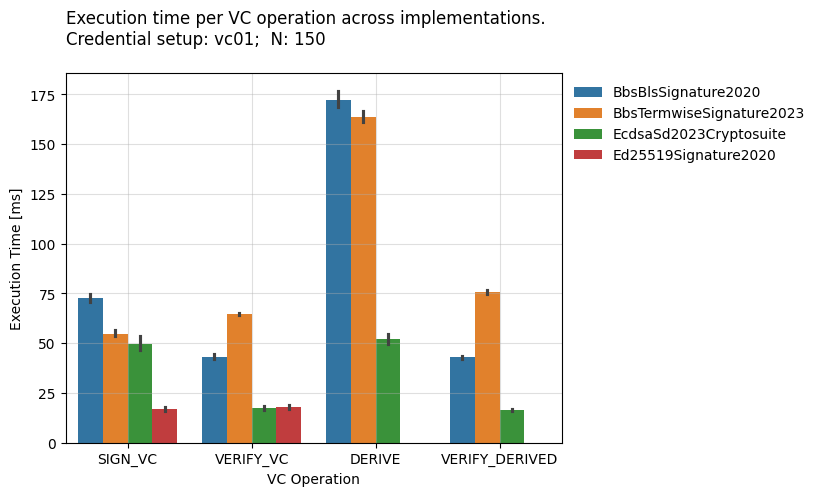

In [14]:
# Compute value counts for credentialSetupKey
csk_vc = dfsb['credentialSetupKey'].value_counts(dropna=False)
if csk_vc.shape[0] != 1:
    raise Exception('This plot is only valid for data sets with a single credentialSetupKey')

csk = csk_vc.index[0]
N = dfsb.iteration.max() + 1

ax = sns.barplot(
    data = dfsb,
    x = 'step',
    y = 'delta',
    hue = 'implementation',
    order=step_order,
    hue_order=implementation_order
)

ax.legend(frameon=False, bbox_to_anchor=(1,1))
ax.set_title(f'''Execution time per VC operation across implementations.
Credential setup: {csk};  N: {N}
''',loc='left')
ax.set_xlabel('VC Operation')
ax.set_ylabel('Execution Time [ms]')
ax.grid(alpha=.4)
plt.show()

In [15]:
df_mean

credentialSetupKey                vc01                           \
implementation     BbsBlsSignature2020 BbsTermwiseSignature2023   
step                                                              
SIGN_VC                          72.60                    54.72   
VERIFY_VC                        42.88                    64.77   
DERIVE                          172.18                   163.82   
VERIFY_DERIVED                   42.81                    75.49   

credentialSetupKey                                              
implementation     EcdsaSd2023Cryptosuite Ed25519Signature2020  
step                                                            
SIGN_VC                             49.82                16.88  
VERIFY_VC                           17.38                17.83  
DERIVE                              51.98                  NaN  
VERIFY_DERIVED                      16.42                  NaN

In [16]:
df_mean.to_clipboard(excel=True)